# Learning by Pruning — 3-Layer Network (LTU)

Same experiment as the 2-layer version, but with **two hidden layers**. No weight updates — only forward passes, utility tracking, and pruning. Uses **LTU activation**.

**Utility function**:
- **Output layer**: v1 — LOO utility shifted by per-output min (all non-negative)
- **Hidden layer propagation**: each upper-layer unit distributes its utility among its positively-contributing inputs, proportional to contribution magnitude

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

from phd.jax_core.models import ltu

# ── Global hyperparameters ────────────────────────────────────────────
HIDDEN1_SIZE = 3200
HIDDEN2_SIZE = 3200
PRUNE_EVERY = 500
PRINT_EVERY = 5_000
TRACE_DECAY = 1.0 - (1.0 / PRUNE_EVERY)
TOTAL_PRUNE_EVENTS = HIDDEN1_SIZE + HIDDEN2_SIZE
N_STEPS = TOTAL_PRUNE_EVENTS * PRUNE_EVERY
RESET_TRACES_ON_PRUNE = False
SEED = 260326
SCAN_UNROLL = 10

In [2]:
# ── Load MNIST ────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = all_images_np / 255.0
all_labels_np = train_dataset.targets.numpy()

INPUT_SIZE = 784
OUTPUT_SIZE = 10
print(f'Loaded {len(all_labels_np)} training images')

Loaded 60000 training images


In [3]:
# ── Initialize network weights and pruning masks ─────────────────────
key = jax.random.PRNGKey(SEED)
k1, k2, k3 = jax.random.split(key, 3)

W1 = jax.random.normal(k1, (INPUT_SIZE, HIDDEN1_SIZE)) * np.sqrt(2.0 / INPUT_SIZE)
b1 = jnp.zeros(HIDDEN1_SIZE)
W2 = jax.random.normal(k2, (HIDDEN1_SIZE, HIDDEN2_SIZE)) * np.sqrt(2.0 / HIDDEN1_SIZE)
b2 = jnp.zeros(HIDDEN2_SIZE)
W3 = jax.random.normal(k3, (HIDDEN2_SIZE, OUTPUT_SIZE)) * np.sqrt(2.0 / HIDDEN2_SIZE)
b3 = jnp.zeros(OUTPUT_SIZE)

mask1 = jnp.ones(HIDDEN1_SIZE)
mask2 = jnp.ones(HIDDEN2_SIZE)
utility_trace1 = jnp.zeros(HIDDEN1_SIZE)
utility_trace2 = jnp.zeros(HIDDEN2_SIZE)

print(f'Network: {INPUT_SIZE} -> {HIDDEN1_SIZE} (ReLU) -> {HIDDEN2_SIZE} (ReLU) -> {OUTPUT_SIZE}')
n_params = W1.size + b1.size + W2.size + b2.size + W3.size + b3.size
print(f'Total parameters: {n_params:,}')

Network: 784 -> 3200 (ReLU) -> 3200 (ReLU) -> 10
Total parameters: 12,787,210


In [4]:
def forward(x, W1, b1, W2, b2, W3, b3, mask1, mask2):
    z1 = x @ W1 + b1
    h1 = ltu(z1) * mask1
    z2 = h1 @ W2 + b2
    h2 = ltu(z2) * mask2
    logits = h2 @ W3 + b3
    return logits, h1, h2


def compute_output_utility(h, W_out, error):
    """V1 utility for the last hidden layer: LOO shifted by per-output min.

    h: (H,), W_out: (H, O), error: (O,) = target - prediction
    Returns (H,) non-negative utility per unit.
    """
    c = W_out * h[:, None]                                    # (H, O)
    U_raw = jnp.abs(error + c) - jnp.abs(error)              # (H, O)
    
    return U_raw.sum(axis=1)
    
    # U_shifted = U_raw - jnp.min(U_raw, axis=0, keepdims=True) # shift per output
    # U = jnp.sum(U_shifted, axis=1)                            # (H,)
    # return U


def propagate_utility(h_below, W, U_above):
    """Distribute utility from upper layer to lower layer.

    Each upper unit distributes its utility among its positively-contributing
    lower-layer inputs, proportional to contribution magnitude.

    h_below: (H_below,), W: (H_below, H_above), U_above: (H_above,)
    Returns (H_below,) non-negative utility.
    """
    contrib = W * h_below[:, None]                             # (H_below, H_above)
    pos_contrib = jnp.maximum(contrib, 0.0)                    # (H_below, H_above)
    total_pos = jnp.sum(pos_contrib, axis=0)                   # (H_above,)
    safe_total = jnp.where(total_pos > 1e-10, total_pos, 1.0)
    share = pos_contrib / safe_total                            # (H_below, H_above)
    return jnp.sum(share * U_above[None, :], axis=1)           # (H_below,)

# def propagate_utility(h_below, W, U_above):
#     pos_weights = jnp.maximum(W, 0.0)                          # (H_below, H_above)
#     total_pos = jnp.sum(pos_weights, axis=0)                    # (H_above,)
#     safe_total = jnp.where(total_pos > 1e-10, total_pos, 1.0)
#     share = pos_weights / safe_total                             # (H_below, H_above)
#     return jnp.sum(share * U_above[None, :], axis=1)            # (H_below,)



def _scan_step(carry, data):
    W1, b1, W2, b2, W3, b3, mask1, mask2, ut1, ut2 = carry
    x, label = data

    logits, h1, h2 = forward(x, W1, b1, W2, b2, W3, b3, mask1, mask2)
    correct = (jnp.argmax(logits) == label).astype(jnp.float32)

    one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)
    error = one_hot - logits

    U2 = compute_output_utility(h2, W3, error)
    U1 = propagate_utility(h1, W2, U2)

    ut2 = ut2 * TRACE_DECAY + U2 * (1 - TRACE_DECAY)
    ut1 = ut1 * TRACE_DECAY + U1 * (1 - TRACE_DECAY)

    carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, ut1, ut2)
    return carry, correct


scan_chunk = jax.jit(
    lambda carry, data: jax.lax.scan(_scan_step, carry, data, unroll=SCAN_UNROLL)
)

In [5]:
# ── Main loop ─────────────────────────────────────────────────────────
assert N_STEPS % PRUNE_EVERY == 0
assert PRINT_EVERY % PRUNE_EVERY == 0
n_prune_events = N_STEPS // PRUNE_EVERY
chunks_per_print = PRINT_EVERY // PRUNE_EVERY

all_corrects = []
n_active1_history = []
n_active2_history = []

rng = np.random.RandomState(SEED)
epoch_order = rng.permutation(len(all_labels_np))
epoch_pos = 0

def get_chunk(size):
    global epoch_order, epoch_pos
    indices = []
    remaining = size
    while remaining > 0:
        avail = len(epoch_order) - epoch_pos
        take = min(avail, remaining)
        indices.append(epoch_order[epoch_pos:epoch_pos + take])
        epoch_pos += take
        remaining -= take
        if epoch_pos >= len(epoch_order):
            epoch_order = rng.permutation(len(all_labels_np))
            epoch_pos = 0
    indices = np.concatenate(indices)
    return all_images_np[indices], all_labels_np[indices]

carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2)

for prune_idx in range(n_prune_events):
    images_chunk, labels_chunk = get_chunk(PRUNE_EVERY)
    data = (jnp.array(images_chunk), jnp.array(labels_chunk))

    carry, corrects = scan_chunk(carry, data)
    all_corrects.append(np.array(corrects))

    W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2 = carry
    n_active1 = int(mask1.sum())
    n_active2 = int(mask2.sum())
    n_active1_history.append(n_active1)
    n_active2_history.append(n_active2)

    # Prune the single lowest-utility unit across both layers
    score1 = jnp.where(mask1 > 0.5, utility_trace1, jnp.inf)
    score2 = jnp.where(mask2 > 0.5, utility_trace2, jnp.inf)
    min1 = jnp.min(score1)
    min2 = jnp.min(score2)

    can_prune1 = n_active1 > 1
    can_prune2 = n_active2 > 1

    if can_prune1 or can_prune2:
        prune_layer1 = can_prune1 and (not can_prune2 or min1 <= min2)
        if prune_layer1:
            worst = jnp.argmin(score1)
            mask1 = mask1.at[worst].set(0.0)
        else:
            worst = jnp.argmin(score2)
            mask2 = mask2.at[worst].set(0.0)

        if RESET_TRACES_ON_PRUNE:
            utility_trace1 = jnp.zeros(HIDDEN1_SIZE)
            utility_trace2 = jnp.zeros(HIDDEN2_SIZE)

    carry = (W1, b1, W2, b2, W3, b3, mask1, mask2, utility_trace1, utility_trace2)

    step_num = (prune_idx + 1) * PRUNE_EVERY
    if step_num % PRINT_EVERY == 0:
        recent_chunks = all_corrects[-chunks_per_print:]
        recent_acc = float(np.concatenate(recent_chunks).mean()) * 100
        print(f'Step {step_num:>7d} | L1: {n_active1:>4d} | L2: {n_active2:>4d} | '
              f'Acc: {recent_acc:.1f}%')

print(f'\nDone. Active units — L1: {int(mask1.sum())} / {HIDDEN1_SIZE}, '
      f'L2: {int(mask2.sum())} / {HIDDEN2_SIZE}')

Step    5000 | L1: 3200 | L2: 3191 | Acc: 12.6%
Step   10000 | L1: 3200 | L2: 3181 | Acc: 11.7%
Step   15000 | L1: 3200 | L2: 3171 | Acc: 11.9%
Step   20000 | L1: 3200 | L2: 3161 | Acc: 11.7%
Step   25000 | L1: 3200 | L2: 3151 | Acc: 11.8%
Step   30000 | L1: 3200 | L2: 3141 | Acc: 12.8%
Step   35000 | L1: 3200 | L2: 3131 | Acc: 13.0%
Step   40000 | L1: 3200 | L2: 3121 | Acc: 12.5%
Step   45000 | L1: 3200 | L2: 3111 | Acc: 13.4%
Step   50000 | L1: 3200 | L2: 3101 | Acc: 14.0%
Step   55000 | L1: 3200 | L2: 3091 | Acc: 14.2%
Step   60000 | L1: 3200 | L2: 3081 | Acc: 15.1%
Step   65000 | L1: 3200 | L2: 3071 | Acc: 15.0%
Step   70000 | L1: 3200 | L2: 3061 | Acc: 15.2%
Step   75000 | L1: 3200 | L2: 3051 | Acc: 15.4%
Step   80000 | L1: 3200 | L2: 3041 | Acc: 15.3%
Step   85000 | L1: 3200 | L2: 3031 | Acc: 15.3%
Step   90000 | L1: 3200 | L2: 3021 | Acc: 15.4%
Step   95000 | L1: 3200 | L2: 3011 | Acc: 15.7%
Step  100000 | L1: 3200 | L2: 3001 | Acc: 16.6%
Step  105000 | L1: 3200 | L2: 2991 | Acc

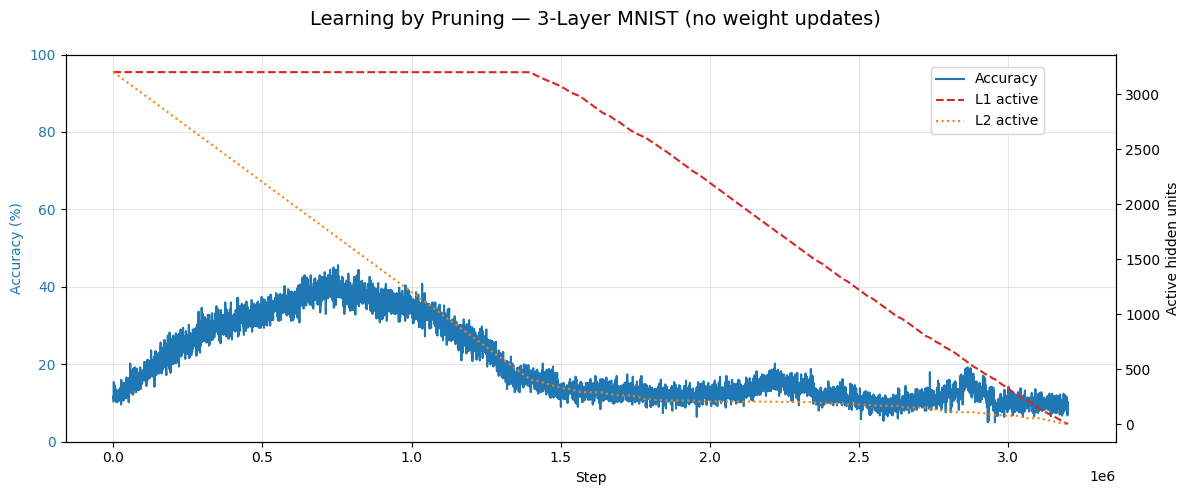

In [7]:
# ── Plot ───────────────────────────────────────────────────────────────
acc_per_interval = [chunk.mean() * 100 for chunk in all_corrects]
interval_centers = [(i + 0.5) * PRUNE_EVERY for i in range(len(acc_per_interval))]

fig, ax1 = plt.subplots(figsize=(12, 5))

color_acc = 'tab:blue'
ax1.plot(interval_centers, acc_per_interval, color=color_acc, linewidth=1.5, label='Accuracy')
ax1.set_xlabel('Step')
ax1.set_ylabel('Accuracy (%)', color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(interval_centers, n_active1_history, color='tab:red', linewidth=1.5,
         linestyle='--', label='L1 active')
ax2.plot(interval_centers, n_active2_history, color='tab:orange', linewidth=1.5,
         linestyle=':', label='L2 active')
ax2.set_ylabel('Active hidden units')

fig.suptitle('Learning by Pruning — 3-Layer MNIST (no weight updates)', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()